Haar-random SU(8) unitary:
[[ 0.048+0.166j -0.097-0.227j -0.302-0.386j -0.41 -0.511j  0.344+0.115j
  -0.008-0.301j -0.061+0.02j  -0.082-0.081j]
 [ 0.072-0.189j -0.136+0.078j  0.466+0.021j -0.225-0.331j  0.127-0.186j
  -0.093+0.259j  0.526+0.386j  0.051-0.048j]
 [ 0.139-0.07j  -0.128-0.18j   0.027+0.405j -0.191-0.17j   0.136+0.065j
   0.409+0.098j -0.033-0.358j  0.56 +0.233j]
 [-0.257+0.288j  0.174-0.13j   0.417+0.351j -0.34 -0.116j -0.24 +0.123j
  -0.285-0.266j -0.012-0.222j -0.254+0.2j  ]
 [ 0.275-0.111j  0.19 -0.201j  0.084-0.213j  0.073-0.193j -0.298-0.694j
  -0.031-0.169j -0.221-0.013j  0.075+0.293j]
 [ 0.062+0.165j  0.436+0.577j -0.05 -0.056j -0.275+0.009j -0.081+0.138j
   0.242-0.129j -0.087+0.376j  0.219+0.259j]
 [-0.477+0.09j   0.206-0.393j -0.015+0.024j -0.218+0.104j  0.07 -0.2j
   0.312+0.424j -0.275+0.314j -0.092-0.07j ]
 [ 0.605-0.19j   0.122-0.092j  0.095+0.111j -0.2  -0.001j -0.183+0.219j
   0.32 +0.144j -0.138-0.008j -0.497-0.207j]]


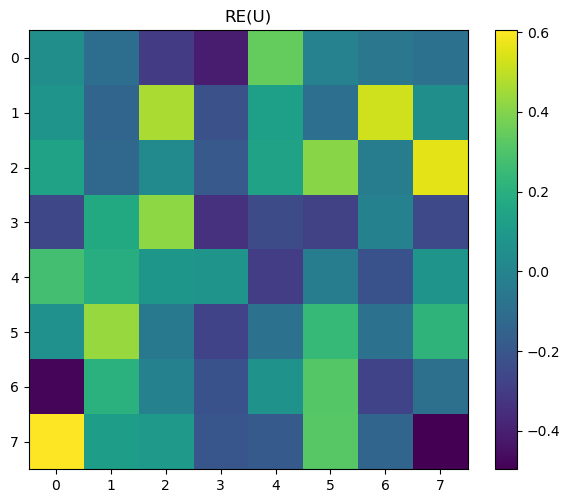

Couplings = [(0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (0, 6), (0, 7), (0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (0, 6), (0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (0, 1), (0, 2), (0, 3), (0, 4), (0, 1), (0, 2), (0, 3), (0, 1), (0, 2), (0, 1)]
Fractions = [0.3450601435983252, 0.8608171011747027, 0.30547415640862446, 0.25967140666978633, 0.26669987981185583, 0.0875504652741988, 0.6382156108442888, 0.8257115050954289, 0.34360750860422296, 0.23943151025269457, 0.20040309457356906, 0.30638914616984125, 0.719884259554109, 0.3838927963874069, 0.22299417818011746, 0.25930925500438295, 0.17043268807281864, 0.7212598540909381, 0.7558315534655198, 0.5532419911167721, 0.1783981803376626, 0.3524130760928239, 0.3772095380198084, 0.6303375695787065, 0.6475528162642669, 0.22130629801541346, 0.6858377182569403, 0.17277110987964495]
Sum of fractions = 11.73170441079487
Phases = [1.524059980165867, 5.097605871335409, 3.017349801872363, 4.1698329459044565, 4.623505537830738, 1.695596194025788, 4.306858290698777

In [9]:
from U_decomp import *
import matplotlib.pyplot as plt
import numpy as np
def haar_unitary(n, rng=None):
    # Haar-random unitary via QR decomposition of complex Gaussian matrix
    rng = np.random.default_rng(rng)
    X = (rng.standard_normal((n, n)) + 1j * rng.standard_normal((n, n))) / np.sqrt(2)
    Q, R = np.linalg.qr(X)
    d = np.diag(R)
    D = d / np.abs(d)
    return Q * D


def haar_su(n, rng=None):
    U = haar_unitary(n, rng)
    phi = np.angle(np.linalg.det(U)) / n
    return U * np.exp(-1j * phi)

dim = 8
U = haar_unitary(dim, rng=2)
print("Haar-random SU(8) unitary:")
print(np.round(U, 3))
# H = (1 / np.sqrt(2)) * np.array([[1, 1], [1, -1]], dtype=complex)
# U = np.kron(H, np.kron(H, H))

plt.figure(figsize=(6, 5))
plt.imshow(np.real(U))
plt.colorbar()
plt.title("RE(U)")
plt.tight_layout()
plt.show()
cpl, frac, phi, frame = unitary_to_pulses(U, center=0, tol=1e-10, use_virtual_z_shortening=False)
print('Couplings =', cpl)
print('Fractions =', frac)
print('Sum of fractions =', sum(frac))
print('Phases =', phi)
print('Frame =', frame)

In [10]:
import numpy as np
from scipy.linalg import expm
from numpy.linalg import norm


def coupling_operator_with_phase(i, j, dim, phi):
    op = np.zeros((dim, dim), dtype=complex)
    op[i, j] = np.exp(+1j * phi)
    op[j, i] = np.exp(-1j * phi)
    return op


def evolver_single_pulse(levels, frac, phi, dim, Omega=1.0):
    i, j = levels
    H = 0.5 * Omega * coupling_operator_with_phase(i, j, dim, phi)
    t = (np.pi * frac) / Omega
    return expm(-1j * H * t)


def unitary_from_pulses_and_frame(couplings, fractions, phases, frame, dim, Omega=1.0, frame_side="left"):
    """
    Reconstruct unitary from:
      - couplings, fractions, phases  (feed to evolver)
      - final frame (per-level phases, radians)

    frame_side:
      - "left"  : U = D(frame) @ U_pulses
      - "right" : U = U_pulses @ D(frame)
      - "none"  : U = U_pulses
    """
    U_seq = np.eye(dim, dtype=complex)
    for (levels, frac, phi) in zip(couplings, fractions, phases):
        U_pulse = evolver_single_pulse(levels, frac, phi, dim, Omega=Omega)
        U_seq = U_pulse @ U_seq  # matches your evolver convention

    if frame is None:
        return U_seq

    D = np.diag(np.exp(-1j * np.asarray(frame)))

    if frame_side == "left":
        return D @ U_seq
    elif frame_side == "right":
        return U_seq @ D
    elif frame_side == "none":
        return U_seq
    else:
        raise ValueError("frame_side must be 'left', 'right', or 'none'")


def check_reconstruction(U_target, couplings, fractions, phases, frame, Omega=1.0):
    dim = U_target.shape[0]
    U_L = unitary_from_pulses_and_frame(couplings, fractions, phases, frame, dim, Omega=Omega, frame_side="left")
    U_R = unitary_from_pulses_and_frame(couplings, fractions, phases, frame, dim, Omega=Omega, frame_side="right")
    eL = norm(U_target - U_L)
    eR = norm(U_target - U_R)
    print("||U - D@U_pulses|| =", eL)
    print("||U - U_pulses@D|| =", eR)
    return U_L, U_R, eL, eR

In [11]:
U_L, U_R, eL, eR = check_reconstruction(U, cpl, frac, phi, frame, Omega=1.0)

||U - D@U_pulses|| = 3.8510776515144873
||U - U_pulses@D|| = 3.5541088269765773


In [3]:
import numpy as np
from numpy.linalg import norm
from scipy.linalg import expm
import matplotlib.pyplot as plt


def coupling_operator_with_phase(i, j, dim, phi):
    op = np.zeros((dim, dim), dtype=complex)
    op[i, j] = np.exp(+1j * phi)
    op[j, i] = np.exp(-1j * phi)
    return op


def evolver_single_pulse(levels, frac, phi, dim, Omega=1.0):
    i, j = levels
    H = 0.5 * Omega * coupling_operator_with_phase(i, j, dim, phi)
    t = (np.pi * frac) / Omega
    return expm(-1j * H * t)


def embed_diag_two_levels(dim, i, j, phase_i, phase_j):
    D = np.eye(dim, dtype=complex)
    D[i, i] = np.exp(1j * phase_i)
    D[j, j] = np.exp(1j * phase_j)
    return D


def _annotate(ax, M, decimals=2):
    M = np.asarray(M)
    vmin, vmax = np.min(M), np.max(M)
    span = (vmax - vmin) if vmax != vmin else 1.0
    for r in range(M.shape[0]):
        for c in range(M.shape[1]):
            val = M[r, c]
            t = (val - vmin) / span
            color = "white" if t > 0.5 else "black"
            ax.text(c, r, f"{val:.{decimals}f}", ha="center", va="center", fontsize=7, color=color)


def compare_rotations_with_local_diag(rotation_mats, cpl, frac, phi, dim, Omega=1.0, max_show=5, tol=1e-8, decimals=2):
    n = min(len(rotation_mats), len(cpl), len(frac), len(phi), max_show)
    print(f"Comparing {n} rotations (TAQR G vs D(gamma)@U_pulse)")

    for k in range(n):
        G = rotation_mats[k]
        (i, j) = cpl[k]

        # gamma from TAQR diagonal phase
        gamma = np.angle(G[i, i])

        U_pulse = evolver_single_pulse(cpl[k], frac[k], phi[k], dim, Omega=Omega)
        D = embed_diag_two_levels(dim, i, j, +gamma, -gamma)
        U_with_diag = D @ U_pulse

        diff_raw = norm(G - U_pulse)
        diff_diag = norm(G - U_with_diag)

        print(
            f"k={k:2d} cpl={cpl[k]} frac={frac[k]:.6f} phi/pi={phi[k]/np.pi:.6f} "
            f"gamma/pi={gamma/np.pi:.6f}  ||G-U||={diff_raw:.3e}  ||G-DU||={diff_diag:.3e}"
        )

        fig, ax = plt.subplots(2, 3, figsize=(12, 7))
        fig.suptitle(f"Rotation {k}: raw vs diag-corrected (||G-DU||={diff_diag:.3e})", fontsize=12)

        ax[0, 0].imshow(np.real(G)); ax[0, 0].set_title("Re(TAQR G)"); _annotate(ax[0, 0], np.real(G), decimals)
        ax[0, 1].imshow(np.imag(G)); ax[0, 1].set_title("Im(TAQR G)"); _annotate(ax[0, 1], np.imag(G), decimals)
        ax[0, 2].imshow(np.abs(G - U_with_diag)); ax[0, 2].set_title("|G - D@U|"); _annotate(ax[0, 2], np.abs(G - U_with_diag), decimals)

        ax[1, 0].imshow(np.real(U_with_diag)); ax[1, 0].set_title("Re(D@U_pulse)"); _annotate(ax[1, 0], np.real(U_with_diag), decimals)
        ax[1, 1].imshow(np.imag(U_with_diag)); ax[1, 1].set_title("Im(D@U_pulse)"); _annotate(ax[1, 1], np.imag(U_with_diag), decimals)
        ax[1, 2].imshow(np.abs(G.conj().T @ U_with_diag)); ax[1, 2].set_title("|G† (D@U)|"); _annotate(ax[1, 2], np.abs(G.conj().T @ U_with_diag), decimals)

        for a in ax.ravel():
            a.set_xticks([]); a.set_yticks([])

        plt.tight_layout()
        plt.show()

        if diff_diag > tol:
            print("  ⚠️ mismatch above tol even after diag-correction\n")

In [4]:
compare_rotations_with_local_diag(rotation_mats, cpl, frac, phi, dim, max_show=3, decimals=2)

NameError: name 'rotation_mats' is not defined